#  Preliminaries

Import libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels as sm
import scipy as sp
import seaborn as sns

Import data:

In [2]:
data = pd.read_csv('bugfixes.csv', sep = " ")

In [3]:
data.shape

(21, 6)

In [4]:
data.isna().any()

dauer            False
programmierer    False
bugtyp           False
codelines        False
usecases         False
alter            False
dtype: bool

In [5]:
data.sort_values('codelines', inplace = True)
data.head()

,dauer,programmierer,bugtyp,codelines,usecases,alter
0,120,Eckkrammer,GUI,183000,49,35
8,159,Eckkrammer,Reporting,203000,61,29
7,184,Mandl,Reporting,228000,57,40
5,178,Meyer,Reporting,243000,85,36
4,157,Eckkrammer,Reporting,305000,71,21


**Summary:**

The data set consists of 21 observations and 6 variables. `dauer`, `bugtyp`, `usecases` and `alter` are numeric, `programmierer` and `bugtyp` are categorical. No values are missing.

# Data Exploration

Visualize `dauer` and `codelines` using histograms and kernel density estimates:

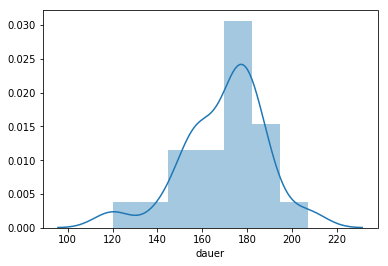

In [6]:
sns.distplot(data.dauer)

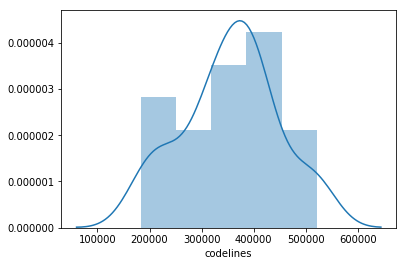

In [7]:
sns.distplot(data.codelines)

Both distributions are slightly left-skewed, codelines is multimodal.

In [8]:
data.describe()

,dauer,codelines,usecases,alter
count,21.000000,21.000000,21.000000,21.000000
mean,169.809524,355285.714286,77.476190,34.904762
std,18.613487,92333.170019,11.948301,7.147760
min,120.000000,183000.000000,49.000000,21.000000
25%,159.000000,305000.000000,73.000000,31.000000
50%,174.000000,364000.000000,79.000000,35.000000
75%,178.000000,401000.000000,85.000000,39.000000
max,207.000000,521000.000000,97.000000,47.000000


In [9]:
data.mad()

dauer           14.331066
codelines    71197.278912
usecases         9.024943
alter            5.442177
dtype: float64

`codelines` has a median of 364000 and a medmed of 71197. `dauer` has a median of 174 and a medmed of 14.33. The non-robust statistics (mean, standard deviation) are distorted by the skewness of the distributions.

# Correlation analysis

Scatter plot to visualize the relationship of `dauer` and `codelines`:

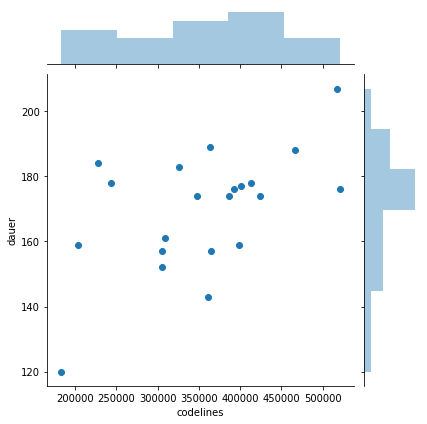

In [10]:
sns.jointplot(data.codelines, data.dauer)

Calculation of Pearson's correlation coefficient (along with P-value for significance test):

In [11]:
sp.stats.pearsonr(data.codelines, data.dauer)

(0.5519805698903371, 0.009477327365881185)

The value is significant at the 0.05 level. Plot and correlation statistic suggest an average correlation of `dauer` and `codelines`.

Spearman's rank correlation coefficient:

In [12]:
sp.stats.spearmanr(data.codelines, data.dauer)

SpearmanrResult(correlation=0.4164777996108111, pvalue=0.06037573784499052)

The more robust rank correlation coefficient is **not** significant at the 0.05 level. Maybe the two extreme values in the bottom left and top right corners are outliers?

# Regression analysis

## Fitting a linear model

In [13]:
model = smf.ols(formula = "dauer ~ codelines", data = data).fit()

In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  dauer   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     8.326
Date:                Wed, 27 Mar 2019   Prob (F-statistic):            0.00948
Time:                        10:20:10   Log-Likelihood:                -86.871
No. Observations:                  21   AIC:                             177.7
Df Residuals:                      19   BIC:                             179.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    130.2755     14.135      9.216      0.000     100.690     159.861
codelines      0.0001   3.86e-05      2.885      0.009    3.06e-05       0.000
==============================================================================
Omnibus:                        0.126   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.939   Jarque-Bera (JB):                0.303
Skew:                          -0.141   Prob(JB):                        0.860
Kurtosis:                       2.484   Cond. No.                     1.49e+06
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.49e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Both parameters (`codelines` and the intercept) are significant at the 0.05 level. The overall model is also significant. The R-squared indicates that the model explains about 30% of the variance of `dauer`.

Confidence intervals for the parameters:

In [15]:
model.conf_int()

,0,1
Intercept,100.690316,159.860590
codelines,0.000031,0.000192


## Regression Formula

E(dauer|codelines) = 130.27 + 0.0001 x codelines

To fix a bug, on the average, at least 130 minutes are required. For every 10.000 codelines, 1 minute is added.

## Regression plot

In [16]:
from statsmodels.stats.outliers_influence import summary_table
st, res, ss2 = summary_table(model)
st

Obs,Dep Var,Predicted,Std Error,Mean ci,Mean ci,Predict ci,Predict ci,Residual,Std Error,Student,Cook's
,Population,Value,Mean Predict,95% low,95% upp,95% low,95% upp,,Residual,Residual,D
1.0,120.0,150.63859932515496,7.497924395446367,134.94526320735116,166.33193544295875,113.79906426063519,187.47813438967472,-30.638599325154956,14.048527983347418,-2.180911719823797,0.6774334685021365
2.0,159.0,152.86407977939348,6.8238416149370495,138.5816151358581,167.14654442292886,116.60309052706538,189.12506903172158,6.135920220606522,14.388022600516672,0.42646028512536405,0.02045421627423402
3.0,184.0,155.6459303471916,6.014178675184565,143.0581097125211,168.23375098186213,120.0183599333358,191.27350076104742,28.35406965280839,14.744818194934805,1.9229853686869256,0.30760668738334423
4.0,178.0,157.3150406878705,5.552115262783908,145.69432989001652,168.93575148572447,122.01756960691378,192.6125117688272,20.684959312129507,14.924946393454391,1.385931899976624,0.13290617939005067
5.0,157.0,164.21403009600988,3.979428680443594,155.8849901450393,172.54307004698046,129.8593586266379,198.56870156538184,-7.214030096009878,15.418954443022011,-0.4678676574775571,0.007290337837484766
6.0,152.0,164.21403009600988,3.979428680443594,155.8849901450393,172.54307004698046,129.8593586266379,198.56870156538184,-12.214030096009878,15.418954443022011,-0.7921438604118485,0.020898240660957645
7.0,161.0,164.65912618685758,3.9065801301279186,156.48256000402648,172.83569236968867,130.34110206241485,198.9771503113003,-3.659126186857577,15.437572361793643,-0.23702730591977836,0.0017988801350330187
8.0,183.0,166.5507845729603,3.653866524344866,158.9031540459094,174.19841510001123,132.35492520458212,200.7466439413385,16.44921542703969,15.499331216571804,1.0612854965930578,0.03129780653541025
9.0,174.0,168.99881307262268,3.486284776419217,161.70193517505993,176.29569097018543,134.87968394663886,203.1179421986065,5.001186927377319,15.537883613814104,0.32187053601888005,0.0026078009649313175


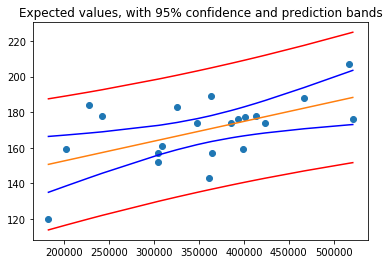

In [17]:
fittedvalues = res[:,2]
predict_mean_ci_low, predict_mean_ci_upp = res[:,4:6].T
predict_ci_low, predict_ci_upp = res[:,6:8].T

#Plot confidence intervals and data points
plt.title("Expected values, with 95% confidence and prediction bands")
plt.plot(data.codelines, data.dauer, 'o')
plt.plot(data.codelines, fittedvalues, '-')
plt.plot(data.codelines, predict_ci_low, 'r-')
plt.plot(data.codelines, predict_ci_upp, 'r-')
plt.plot(data.codelines, predict_mean_ci_low, 'b-')
plt.plot(data.codelines, predict_mean_ci_upp, 'b-')
#plt.savefig('regression_plot.pdf')

## Residual diagnostics

The above mentioned significance tests are only valid if certain assumptions are fulfilled.

### Normality of residuals

If the sample size is small (rule of thumb: N < 70), then the residuals (= observed - expected values) have to follow a normal distribution. This can be checked usind a Q-Q-Plot comparing the empirical quantiles of the residuals with the quantiles of a normal distribution. All points should be more or less on a straight line, especially at the ends.

In [18]:
from statsmodels.graphics.gofplots import qqplot

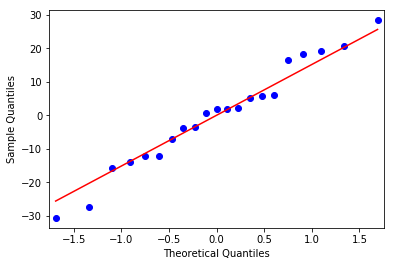

In [19]:
residuals = res[:,8]
fig = qqplot(residuals, line = 's')

The plot basically looks OK, except the two points in the lower left part.

### Remaining structure in residuals

If the model fits well, the residuals really should just be noise, so there should be no correlation between the fitted values and the residuals:

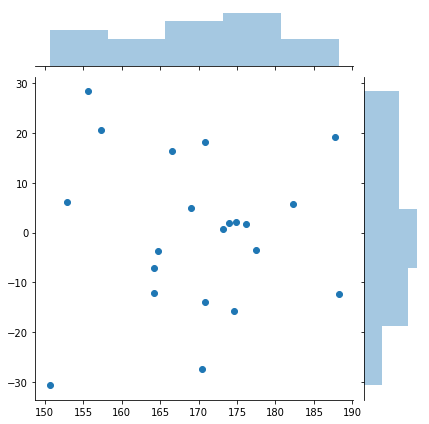

In [20]:
fig = sns.jointplot(fittedvalues, residuals)

Looks fine: the scatterplot clearly shows no structure, and the correlation is also 0.

### Homoscedasticity of residuals

The last assumption to be checked is that variance of the residuals is the same for all values of the predictors (`codelines`). We just need to plot the residuals against `codelines` to see if the values are more or less on the same scale:

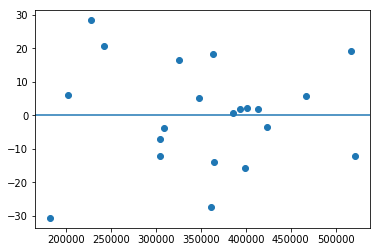

In [21]:
plt.plot(data.codelines, residuals, "o")
plt.axhline() # horizontal line

Basically, looks fine - no special tendencies can be seen. (Maybe the variance is higher at the beginning? But the sample size is to small to judge).

## Predictions

Predict bugfix time for 250.000 codelies (interpolation) and 600.000 codelines (extrapolation):

In [22]:
newdata = pd.DataFrame({'codelines' : [250000, 600000]})
newdata

,codelines
0,250000
1,600000


Just predict the expected values:

In [23]:
model.predict(newdata)

0    158.093959
1    197.039867
dtype: float64

To additionally get intervals for the *individual* predictions:

In [24]:
model.get_prediction(newdata).summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,158.093959,5.344247,146.908321,169.279597,122.937323,193.250595
1,197.039867,10.056658,175.991041,218.088693,157.620029,236.459705


# More than two variables

## Pairwise correlations

In [25]:
data.corr()

,dauer,codelines,usecases,alter
dauer,1.000000,0.551981,0.532579,0.119741
codelines,0.551981,1.000000,0.853550,-0.119431
usecases,0.532579,0.853550,1.000000,-0.023446
alter,0.119741,-0.119431,-0.023446,1.000000


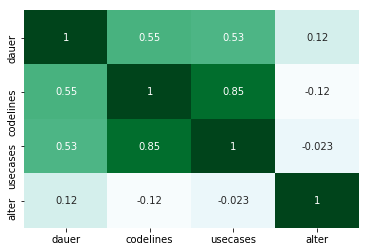

In [27]:
sns.heatmap(data.corr(), annot = True, cbar = False, cmap = "BuGn")

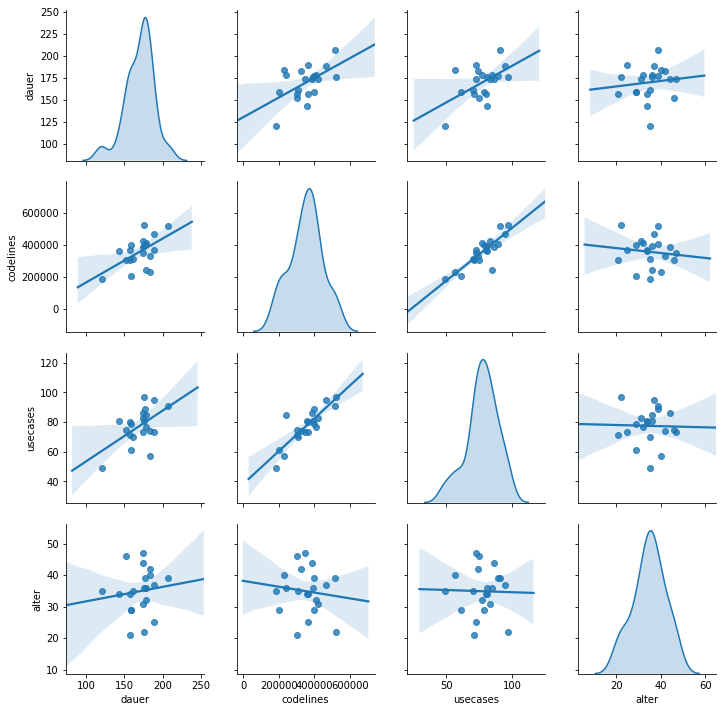

In [28]:
sns.pairplot(data, kind = "reg", diag_kind = "kde")

## Regression models with more than one predictor

In the regression formula, just add predictors with the `+` operator:

In [29]:
model = smf.ols(formula = "dauer ~ codelines + usecases", data = data).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  dauer   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     4.208
Date:                Wed, 27 Mar 2019   Prob (F-statistic):             0.0317
Time:                        10:20:16   Log-Likelihood:                -86.659
No. Observations:                  21   AIC:                             179.3
Df Residuals:                      18   BIC:                             182.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    116.7953     26.485      4.410      0.000      61.153     172.437
codelines   7.233e-05   7.53e-05      0.961      0.349   -8.58e-05       0.000
usecases       0.3526      0.582      0.606      0.552      -0.870       1.575
==============================================================================
Omnibus:                        0.003   Durbin-Watson:                   2.119
Prob(Omnibus):                  0.998   Jarque-Bera (JB):                0.183
Skew:                          -0.011   Prob(JB):                        0.913
Kurtosis:                       2.543   Cond. No.                     2.75e+06
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.75e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""